# MÓDULO 39 - XGBoost
## Predição de Intenção de Compra 

### Contexto

A previsão da intenção de compra em sites de e‑commerce é um recurso estratégico para aprimorar a experiência do cliente e direcionar de forma eficaz as ações de marketing da empresa. A análise dos dados demográficos (idade, gênero), renda e comportamento de compra pode revelar padrões que indicam maior probabilidade de realizar compras online.

### 🎯 Objetivo Geral

Desenvolver um modelo preditivo para identificar clientes com maior propensão a comprar (variável `Purchased`).

### Objetivos Complementares

* **Pré-processamento:** tratar variáveis irrelevantes, codificar categóricas e checar valores faltantes.
* **Modelagem:** treinar um classificador XGBoost para predizer `Purchased`.
* **Avaliação:** calcular métricas (acurácia, precisão, recall, F1, AUC) e analisar a importância das features.

---

## 🗄️ Base de Dados

A amostra fornecida tem as colunas:

| Feature      | Descrição                            |
| ------------ | ------------------------------------ |
| User ID      | Identificador do cliente (remover)   |
| Gender       | Sexo do cliente (Male / Female)      |
| Age          | Idade                                |
| AnnualSalary | Renda anual                          |
| Purchased    | Target: 0 = não comprou, 1 = comprou |

---
### 🎯 **Destaques do Projeto**

* **Base de Dados:** 1.000 registros válidos com 4 variáveis — *Gender*, *Age*, *AnnualSalary* e *Purchased*. Não há valores nulos. As 57 duplicatas foram mantidas por representarem repetições plausíveis entre indivíduos diferentes.
* **Pré-processamento:** Remoção de *User ID* e codificação de *Gender* via *LabelEncoder* (*Gender_encoded*), garantindo compatibilidade com modelos de aprendizado de máquina.
* **Análise Exploratória (EDA):** A maioria dos clientes tem entre 30 e 50 anos e renda média de R$ 72 mil anuais. Cerca de 40% realizaram compras. As variáveis *Age* (0.616) e *AnnualSalary* (0.365) apresentaram correlação positiva com *Purchased*.
* **Modelagem:** O modelo XGBoost (*binary:logistic*) obteve **Acurácia = 0.905** e **AUC = 0.97**, indicando excelente desempenho.
* **Avaliação:** *Precision* e *recall* equilibrados entre as classes, com alta taxa de acerto para compradores e não compradores.
* **Importância das Features:** *Age* foi o principal fator (1.76), seguido por *AnnualSalary* (1.07) e *Gender_encoded* (0.44), mostrando que idade e renda são determinantes na decisão de compra.

### 💡 **Insights Estratégicos**
* **Perfil do Comprador:** Clientes mais velhos e com maior renda tendem a comprar mais.
* **Gênero Irrelevante:** O gênero não influencia o comportamento de compra — estratégias neutras são mais eficazes.
* **Segmentação Eficiente:** Campanhas focadas em idade e renda aumentam conversão e reduzem custos.
* **Alto Potencial do Modelo:** A AUC = 0.97 confirma o uso do modelo para identificar leads qualificados.



In [1]:
# Bibliotecas padrão
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Machine Learning
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


### 1. Carregamento da base de dados 
ANÁLISE EXPLORATÓRIA DOS DADOS


In [2]:
dfo = pd.read_csv("/home/akel/PycharmProjects/EBAC/dados/CARRO_CLIENTES.csv", delimiter=',')
dfo.drop(columns=['User ID'], inplace=True)
# Verificações

In [3]:
df=dfo.copy()
print("=" * 50)
print("ANÁLISE EXPLORATÓRIA DO DATAFRAME")
print("=" * 50)
# Informações sobre o shape dos dados
print(f"\n📊 DIMENSÕES: {df.shape[0]} linhas × {df.shape[1]} colunas")

# Informações sobre tipos de dados
print(f"\n🔧 TIPOS DE DADOS:")
print(df.dtypes.to_frame('Tipo').to_markdown())

# Contagem de duplicatas
print("=" * 50)
print("🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos")
print(f"Total registros duplicados: {df.duplicated().sum()}")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")

df.describe()

ANÁLISE EXPLORATÓRIA DO DATAFRAME

📊 DIMENSÕES: 1000 linhas × 4 colunas

🔧 TIPOS DE DADOS:
|              | Tipo   |
|:-------------|:-------|
| Gender       | object |
| Age          | int64  |
| AnnualSalary | int64  |
| Purchased    | int64  |
🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos
Total registros duplicados: 57
Total de valores nulos: 0


,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


#### *Comentário*
Ao identificar duplicatas em um conjunto de dados que contém as variáveis **Gender**, **Age**, **AnnualSalary** e **Purchased**, excluindo o identificador único **User ID**, é importante compreender o significado dessas repetições antes de decidir se devem ou não ser removidas. Nesse caso, as duplicatas podem representar duas situações distintas: registros realmente repetidos (erro de coleta ou processamento) ou observações legítimas de pessoas diferentes que possuem exatamente os mesmos atributos demográficos e comportamento de compra.

Considerando o contexto desta atividade, adotaremos  em que **cada linha representa um indivíduo único**, ou seja, clientes diferentes que, por coincidência, possuem o mesmo sexo, idade, renda anual e decisão de compra. Essa situação é perfeitamente plausível, especialmente em bases com número limitado de variáveis explicativas, nas quais a combinação de atributos pode naturalmente se repetir. 

### 2. Label Encoder
PRÉ-PROCESSAMENTO E ENGENHARIA DE FEATURES


In [4]:
df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])
df = df.drop(columns=['Gender'])
df = df[['Age', 'AnnualSalary', 'Gender_encoded', 'Purchased']]

### 3. Matriz de correlação
ANÁLISE DE CORRELAÇÃO


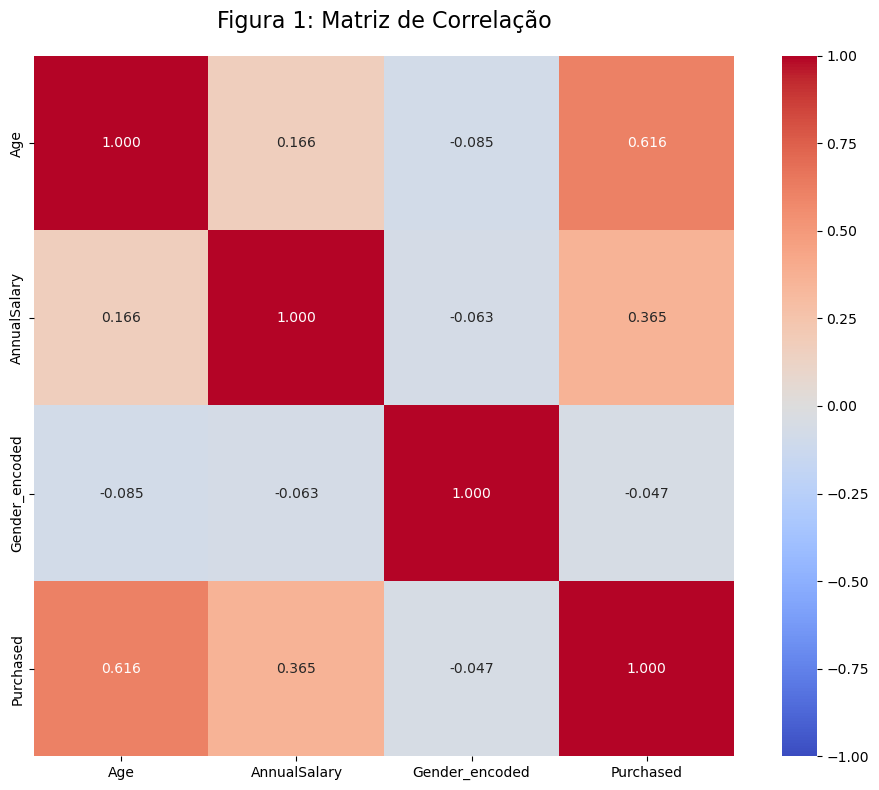


CORRELAÇÃO COM VARIÁVEL TARGET (Purchased)

📊 CORRELAÇÃO ABSOLUTA COM PURCHASED:
Age                  : 0.6160 (+)
AnnualSalary         : 0.3650 (+)
Gender_encoded       : 0.0472 (-)


,Age,AnnualSalary,Gender_encoded,Purchased
Age,1.000000,0.166042,-0.084760,0.616036
AnnualSalary,0.166042,1.000000,-0.063301,0.364974
Gender_encoded,-0.084760,-0.063301,1.000000,-0.047211
Purchased,0.616036,0.364974,-0.047211,1.000000


In [5]:
# Calcular matriz de correlação
df_corr = df.corr()

# Plotar heatmap de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    center=0,
    square=True,
    fmt='.3f'
)
plt.title('Figura 1: Matriz de Correlação', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# %%
# ANÁLISE DE CORRELAÇÃO COM TARGET
print('\n' + '=' * 50)
print('CORRELAÇÃO COM VARIÁVEL TARGET (Purchased)')
print('=' * 50)

# Variáveis mais correlacionadas com o target (excluindo a própria variável target)
corr_target = df_corr['Purchased'].abs().sort_values(ascending=False)
corr_target = corr_target[corr_target.index != 'Purchased']  # Remove a própria variável

print("\n📊 CORRELAÇÃO ABSOLUTA COM PURCHASED:")
for var, corr_val in corr_target.items():
    correlacao_real = df_corr.loc[var, 'Purchased']
    sinal = "(+)" if correlacao_real > 0 else "(-)" if correlacao_real < 0 else "(0)"
    print(f'{var:20} : {corr_val:.4f} {sinal}')
df_corr 

### 4. Separação da base em X e Y e em seguida nas bases de treino e teste.

In [6]:
X = df.drop('Purchased', axis=1)  # X contém todas as colunas exceto 'Purchased'
y = df['Purchased']  # Y contém apenas a coluna 'Purchased'
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. Treino o modelo Xgboost com sua base de treino.


In [7]:
model_xgboost = xgb.XGBClassifier().fit(X_train, y_train)
model_xgboost.objective

'binary:logistic'

### 6. Previsões e Probabilidades para a base de teste

In [8]:
y_pred = model_xgboost.predict(X_test)  # previsão             
y_pred_prob = model_xgboost.predict_proba(X_test)  #probabilidade
# mostrar algumas previsões e probabilidades
result_df = X_test.copy()
result_df['y_true'] = y_test.values
result_df['y_pred'] = y_pred
result_df['y_pred_prob'] = y_pred_prob[:,1]
print("🎯 ANÁLISE DAS PREVISÕES")
print("═" * 85)

analysis_df = result_df.head(20).copy()
analysis_df['Status'] = analysis_df.apply(
    lambda row: '✅ ACERTO' if row['y_true'] == row['y_pred'] else '❌ ERRO', axis=1
)
analysis_df['Probabilidade 1'] = analysis_df['y_pred_prob'].map('{:.1%}'.format)

display_cols = ['Age', 'AnnualSalary', 'y_true', 'y_pred', 'Probabilidade 1', 'Status']
print(analysis_df[display_cols].to_string(index=False))

🎯 ANÁLISE DAS PREVISÕES
═════════════════════════════════════════════════════════════════════════════════════
 Age  AnnualSalary  y_true  y_pred Probabilidade 1   Status
  41         73500       0       0            8.4% ✅ ACERTO
  59        135500       1       1           89.2% ✅ ACERTO
  25         59500       0       0            0.0% ✅ ACERTO
  47         42500       1       0            8.2%   ❌ ERRO
  46        135500       0       1           74.1%   ❌ ERRO
  53         90500       1       1           99.6% ✅ ACERTO
  55         39000       1       1          100.0% ✅ ACERTO
  36         63000       0       0            0.0% ✅ ACERTO
  41         67500       0       0            0.2% ✅ ACERTO
  32         77500       0       0            0.2% ✅ ACERTO
  41         76500       0       0            0.7% ✅ ACERTO
  28         55500       0       0            0.0% ✅ ACERTO
  40         82500       0       0            7.1% ✅ ACERTO
  35         44000       0       0            0.0%

### 7. Transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [9]:
# Transformação das probabilidades
#Compara cada probabilidade da classe 1 com o limiar de 0.5 e
# retorna True se probabilidade > 0.5, False caso contrário.
y_pred_binary = (y_pred_prob[:, 1] > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_binary)
report = classification_report(y_test,y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.905
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       112
           1       0.92      0.86      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200

Matriz de Confusão:
[[105   7]
 [ 12  76]]


#### CURVA AUC - ROC

AUC: 0.97


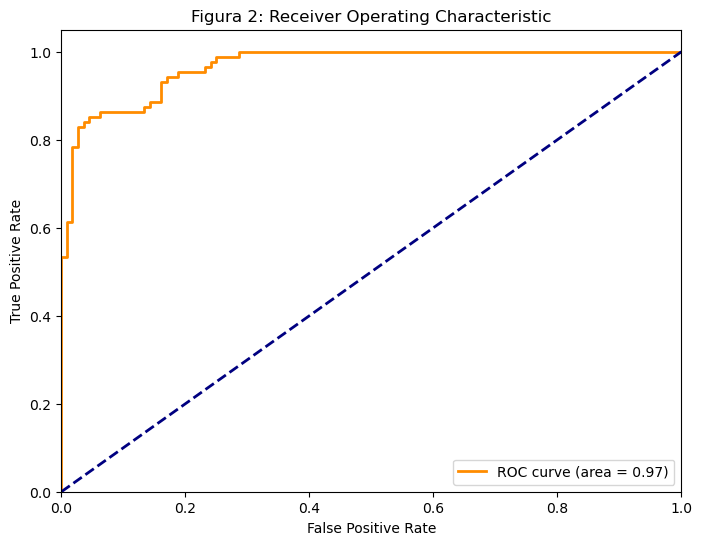

In [10]:
fpr, tpr, thresholds = roc_curve(y_test,y_pred_prob[:, 1])
# Calcular a AUC
roc_auc = roc_auc_score(y_test,y_pred_prob[:, 1])

print("AUC: {:.2f}".format(roc_auc))

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figura 2: Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 8. Listagem da feature importance.


          feature      gain
0             Age  1.761586
1    AnnualSalary  1.071680
2  Gender_encoded  0.444215


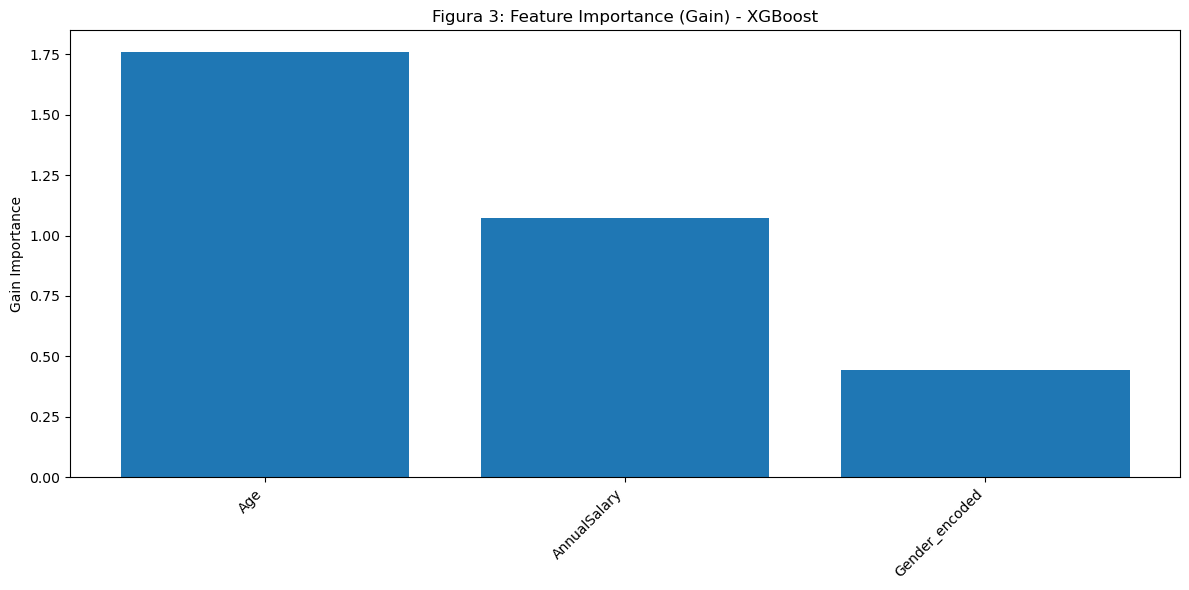

In [11]:
# Obter as importâncias pelo método 'gain'
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Converter para DataFrame
feat_imp = pd.DataFrame(list(importances.items()), columns=['feature', 'gain'])
feat_imp = feat_imp.sort_values(by='gain', ascending=False)

print(feat_imp)

# Plot simples
fig, ax = plt.subplots(figsize=(12,6))
ax.bar(feat_imp['feature'], feat_imp['gain'])
ax.set_xticks(range(len(feat_imp)))
ax.set_xticklabels(feat_imp['feature'], rotation=45, ha='right')
ax.set_ylabel('Gain Importance')
ax.set_title('Figura 3: Feature Importance (Gain) - XGBoost')
plt.tight_layout()
plt.show()
